<a href="https://colab.research.google.com/github/ReemaE-Git/Multi-targeting-Cancer-Protein-Prediciton-Model/blob/main/notebooks/Gene_high_coexpression_pairs_and_trios_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import tensorflow as tf
import keras
from keras import layers
import itertools
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report,roc_auc_score, roc_curve
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


Adding to ensure reproducibility.

In [2]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

## 1. Load, clean & map gene names

In [3]:
#reading in csv file
df = pd.read_csv(
    "https://raw.githubusercontent.com/ReemaE-Git/Multi-targeting-Cancer-Protein-Prediciton-Model/main/data/denseDataOnlyDownload-2.tsv",
    sep='\t'
)

#mapping csv file names to gene markers, then renaming columns
ensembl_map = {
    'ENSG00000082175.15': 'PGR',
    'ENSG00000141736.14': 'ERBB2',
    'ENSG00000087586.18': 'SLAMF7',
    'ENSG00000171862.11': 'PTEN',
    'ENSG00000146648.19': 'EGFR',
    'ENSG00000103855.18': 'CD276',
    'ENSG00000090339.9':  'ICAM1'
}
df = df.rename(columns=ensembl_map)
df = df.rename(columns={'sample_type.samples':'sample_type','primary_diagnosis.diagnoses':'primary_diagnosis'})
GENES = list(ensembl_map.values())

# Remove nulls
before = len(df)
df = df.dropna(subset=GENES + ['sample_type'])
print(f'Removed {before-len(df)} rows with nulls → {len(df)} samples remaining')
print(f'Sample types:\n{df["sample_type"].value_counts()}')

Removed 31 rows with nulls → 1226 samples remaining
Sample types:
sample_type
Primary Tumor          1106
Solid Tissue Normal     113
Metastatic                7
Name: count, dtype: int64


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Split tumor vs normal

In [5]:
#combining Primary Tumor and Metastatics into one type
# combining dataframes into one
tumor  = df[df['sample_type'].isin(['Primary Tumor','Metastatic'])].copy()
normal = df[df['sample_type'] == 'Solid Tissue Normal'].copy()
combined = pd.concat([tumor, normal], ignore_index=True)
combined['label'] = (combined['sample_type'].isin(['Primary Tumor','Metastatic'])).astype(int)
print(f'Tumor samples:  {len(tumor)}')
print(f'Normal samples: {len(normal)}')

Tumor samples:  1113
Normal samples: 113


In [6]:
#showing combined dataframe head
print(combined.shape)
combined.head()

(1226, 15)


,sample,samples,sample_type,disease_type,primary_diagnosis,primary_site,disease_type.1,PGR,ERBB2,SLAMF7,PTEN,EGFR,CD276,ICAM1,label
0,TCGA-AC-A6IX-06A,TCGA-AC-A6IX-06A,Metastatic,Ductal and Lobular Neoplasms,"Lobular carcinoma, NOS",Breast,Ductal and Lobular Neoplasms,0.2133,4.851,2.016,3.410,1.5460,4.185,3.049,1
1,TCGA-E2-A15E-06A,TCGA-E2-A15E-06A,Metastatic,Ductal and Lobular Neoplasms,"Infiltrating duct carcinoma, NOS",Breast,Ductal and Lobular Neoplasms,5.9380,7.051,2.208,4.504,0.6054,4.580,2.958,1
2,TCGA-E2-A15A-06A,TCGA-E2-A15A-06A,Metastatic,Ductal and Lobular Neoplasms,"Infiltrating duct carcinoma, NOS",Breast,Ductal and Lobular Neoplasms,2.8910,5.271,4.435,2.536,0.9872,4.173,3.025,1
3,TCGA-BH-A1FE-06A,TCGA-BH-A1FE-06A,Metastatic,Ductal and Lobular Neoplasms,"Infiltrating duct carcinoma, NOS",Breast,Ductal and Lobular Neoplasms,2.8380,3.028,2.612,3.743,3.2020,5.287,5.570,1
4,TCGA-BH-A1ES-06A,TCGA-BH-A1ES-06A,Metastatic,Ductal and Lobular Neoplasms,"Infiltrating duct carcinoma, NOS",Breast,Ductal and Lobular Neoplasms,2.5050,5.889,2.560,3.898,1.6520,4.293,4.300,1


# 3. Finding pairs and trios

## Using gene-gene correlation
For pairs, we rank pairs of genes by their correlation score and return the top 5 scoring pairs. For the trio of genes, we compute every pairwise corrrelation and find the average of the of all three correlations. We then sort the list of all trio combinations and return the top 5 trios.

In [7]:
#defining gene markers
features = ['PGR', 'ERBB2', 'SLAMF7', 'PTEN', 'EGFR', 'CD276', 'ICAM1']

#compute correlation matrix
corr_matrix = combined[features].corr(method='spearman')

#finding top pairs
pair_scores = []
for g1, g2 in itertools.combinations(features, 2):
    score = corr_matrix.loc[g1, g2]
    pair_scores.append((g1, g2, round(score, 4)))

#sorting all pair_scores and getting the top five
top_pairs1 = sorted(pair_scores, key=lambda x: x[2], reverse=True)[:5]

#printing results
print("\n=== TOP 5 PAIRS (highest co-expression) ===")
for g1, g2, score in top_pairs1:
    print(f"{g1} + {g2}: {score}")

#finding top trios
trio_scores = []
for g1, g2, g3 in itertools.combinations(features, 3):
    s12 = corr_matrix.loc[g1, g2]
    s13 = corr_matrix.loc[g1, g3]
    s23 = corr_matrix.loc[g2, g3]
    avg_score = round((s12 + s13 + s23) / 3, 4)
    trio_scores.append((g1, g2, g3, avg_score))

#sorting all trio_scores and getting the top five
top_trios1 = sorted(trio_scores, key=lambda x: x[3], reverse=True)[:5]

#printing results
print("\n=== TOP 5 TRIOS (by average pairwise co-expression) ===")
for g1, g2, g3, score in top_trios1:
    print(f"{g1} + {g2} + {g3}: {score}")



=== TOP 5 PAIRS (highest co-expression) ===
EGFR + ICAM1: 0.3489
PGR + PTEN: 0.3012
SLAMF7 + CD276: 0.2686
PTEN + EGFR: 0.2351
CD276 + ICAM1: 0.2197

=== TOP 5 TRIOS (by average pairwise co-expression) ===
EGFR + CD276 + ICAM1: 0.1856
PTEN + EGFR + ICAM1: 0.1848
SLAMF7 + CD276 + ICAM1: 0.1835
ERBB2 + SLAMF7 + CD276: 0.1301
PGR + ERBB2 + PTEN: 0.1033


## Using an Autoencoder model
We train an Autoencoder to learn to compress the input data and then reconstruct the output as closely to its original input. During the encoding phase, the input data get compressed into a latent space which we will use to compare gene coexpression. In the low-dimensional latent space it is easier to compare how close two vectors are;In this case, each vector encodes a single gene expression.

In [8]:
#transposing features for normalization
expr = combined[features].T

#scaling data
scaler = StandardScaler()
expr_norm = scaler.fit_transform(expr.T).T
expr_norm = pd.DataFrame(expr_norm, index=features)
expr_norm = pd.DataFrame(expr_norm, index=features)

###  Describing Autoencoder network

In [9]:
# match transposed data dimension for input
input_dim = expr.shape[1]

#the compressed lower dimension representation created by the encoder
latent_dim = 16

inputs = keras.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(128, activation='relu')(inputs)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(latent_dim, name='embedding_layer')(encoded)
# Decoder
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(input_dim, name='reconstruction')(decoded)

#declare full Autoencoder for training
autoencoder = keras.Model(inputs, decoded, name="Gene_Autoencoder")

#declare encoder for our embedding
encoder = keras.Model(inputs, encoded, name="Gene_Encoder")

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "Gene_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1226)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       157,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Dense)         │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 1226)           │       158,154 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,914 (1.27 MB)

 Trainable params: 333,914 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

### Training
We utilize early stopping to prevent overfitting, since we are only using 7 genes in total. The Early stopping monitors the model's loss and waits 50 epochs for the model's performance to improve before stopping training.

In [10]:
#setting up Keras early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='loss', patience=50, restore_best_weights=True
)

#fitting autoencoder model with early stopping
history = autoencoder.fit(
    expr_norm, expr_norm,          # input = target (reconstruction)
    epochs=500,
    batch_size=7,                  # full batch on 7 genes
    shuffle=True,
    callbacks=[early_stop],
    verbose=0
)

print(f"Training finished after {len(history.history['loss'])} epochs")

Training finished after 165 epochs


### Extract Embeddings and Compute Co-Expression
We use the trained encoder to extract a lower-dimensional representation of the normalized gene expression data. Then we utilize cosine_similarity() to compute how closely two genes are from each other. This is analogues of a correlation matrix but using the non-linear patterns that our encoder learned.

In [11]:
#Extracting embeddings from normalized gene expression data
embeddings = encoder(expr_norm, training=False).numpy()

# Cosine similarity matrix, aka learned co-expression
sim_matrix = cosine_similarity(embeddings)

### Ranking pairs and trio of genes
Using embedding to find cosine similarites and rank by similairty score.

In [12]:
#Top 5 pairs and Top 5 trios
#go through all pair combinations of genes and add cosine similarity score to matrix
pair_scores = []
for i, j in itertools.combinations(range(len(features)), 2):
    score = sim_matrix[i, j]
    pair_scores.append((features[i], features[j], round(float(score), 4)))

#sort pair_score array and return top 5
top_pairs2 = sorted(pair_scores, key=lambda x: x[2], reverse=True)[:5]

#showing results
print("\n=== TOP 5 PAIRS (Autoencoder cosine co-expression) ===")
for g1, g2, score in top_pairs2:
    print(f"{g1} + {g2}: {score}")

#go through all trio combinations of genes
#look at pairwise cosine similarity score
#average scores to get one final trio score
#then add to trio scores
trio_scores = []
for i, j, k in itertools.combinations(range(len(features)), 3):
    s12 = sim_matrix[i, j]
    s13 = sim_matrix[i, k]
    s23 = sim_matrix[j, k]
    avg_score = round((s12 + s13 + s23) / 3, 4)
    trio_scores.append((features[i], features[j], features[k], avg_score))

#sort trio_score array then return the top 5
top_trios2 = sorted(trio_scores, key=lambda x: x[3], reverse=True)[:5]

#show results
print("\n=== TOP 5 TRIOS (by average cosine) ===")
for g1, g2, g3, score in top_trios2:
    print(f"{g1} + {g2} + {g3}: {score:.4f} (avg)")


=== TOP 5 PAIRS (Autoencoder cosine co-expression) ===
ERBB2 + SLAMF7: 0.4351
ERBB2 + CD276: 0.4337
SLAMF7 + CD276: 0.3238
PGR + ERBB2: 0.2776
PTEN + EGFR: 0.2697

=== TOP 5 TRIOS (by average cosine) ===
ERBB2 + SLAMF7 + CD276: 0.3975 (avg)
PGR + ERBB2 + SLAMF7: 0.2953 (avg)
PGR + ERBB2 + CD276: 0.2210 (avg)
PGR + PTEN + EGFR: 0.2209 (avg)
PGR + ERBB2 + PTEN: 0.1991 (avg)


## 4. Evaluating pairs and trios
We evalute each of the top 5 pairs and trios to measure their ability to distingish between tumor and normal samples.

In [13]:
#defining function to calulate metrics from gene pairs or trios
def evaluate_combo(df, gene_list, name):
    #creating substitute dataframe from pair or trio gene list
    sub = df[gene_list + ['label']].copy()

    # calculating several gene_list statistics for statistical tests
    sub['avg_score'] = sub[gene_list].mean(axis=1)
    sub['pca_score'] = StandardScaler().fit_transform(sub[gene_list]).mean(axis=1)
    sub['geo_mean'] = np.exp(np.log(sub[gene_list].clip(lower=1e-6)).mean(axis=1))

    #creating results object with name and gene_list
    results = {'name': name, 'genes': gene_list}

    #calculating statistical test for each score
    for score_name in ['avg_score', 'pca_score', 'geo_mean']:
        scores = sub[score_name]
        tumor = scores[sub['label'] == 1]
        normal = scores[sub['label'] == 0]

        # Statistical tests: T-test and Mann-Whitney U test
        _, t_p = stats.ttest_ind(tumor, normal, equal_var=False)
        _, mw_p = stats.mannwhitneyu(tumor, normal, alternative='two-sided')

        # Calculate standardized effect size for Cohen's d
        pooled_std = np.sqrt((tumor.var(ddof=1) + normal.var(ddof=1)) / 2)
        cohen_d = (tumor.mean() - normal.mean()) / pooled_std if pooled_std > 0 else 0

        #calculating ROC-AUC
        auc = roc_auc_score(sub['label'], scores)

        #adding each statistical test result to result object in a formatted way
        results[f'{score_name}_auc'] = round(auc, 4)
        results[f'{score_name}_cohen_d'] = round(cohen_d, 3)
        results[f'{score_name}_mw_p'] = f"{mw_p:.2e}"
        results[f'{score_name}_t_p'] = f"{t_p:.2e}"

    return results

In [14]:
#running evaluation
print("=== EVALUATION OF PAIRS & TRIOS (Spearman's correlation) ===\n")
all_results1 = []

#perform for pairs
for p1, p2,*others in top_pairs1:
    res = evaluate_combo(combined, [p1,p2], f"Pair: {p1} + {p2}")
    all_results1.append(res)
    print(f"{res['name']:25} | AUC (avg): {res['avg_score_auc']:.4f} | Cohen's d: {res['avg_score_cohen_d']:.3f} | MW-p: {res['avg_score_mw_p']}")

#newline for neater format
print()

#performing for trios
for t1,t2,t3,*other in top_trios1:
    res = evaluate_combo(combined, [t1,t2,t3], f"Trio: {t1} + {t2} + {t3}")
    all_results1.append(res)
    print(f"{res['name']:29} | AUC (avg): {res['avg_score_auc']:.4f} | Cohen's d: {res['avg_score_cohen_d']:.3f} | MW-p: {res['avg_score_mw_p']}")

=== EVALUATION OF PAIRS & TRIOS (Spearman's correlation) ===

Pair: EGFR + ICAM1        | AUC (avg): 0.1290 | Cohen's d: -1.499 | MW-p: 1.07e-38
Pair: PGR + PTEN          | AUC (avg): 0.3470 | Cohen's d: -0.579 | MW-p: 8.00e-08
Pair: SLAMF7 + CD276      | AUC (avg): 0.9779 | Cohen's d: 2.872 | MW-p: 4.61e-63
Pair: PTEN + EGFR         | AUC (avg): 0.0335 | Cohen's d: -2.686 | MW-p: 3.73e-60
Pair: CD276 + ICAM1       | AUC (avg): 0.7413 | Cohen's d: 0.891 | MW-p: 2.61e-17

Trio: EGFR + CD276 + ICAM1    | AUC (avg): 0.2427 | Cohen's d: -0.856 | MW-p: 1.81e-19
Trio: PTEN + EGFR + ICAM1     | AUC (avg): 0.0928 | Cohen's d: -1.809 | MW-p: 2.87e-46
Trio: SLAMF7 + CD276 + ICAM1  | AUC (avg): 0.9385 | Cohen's d: 2.128 | MW-p: 2.33e-53
Trio: ERBB2 + SLAMF7 + CD276  | AUC (avg): 0.9695 | Cohen's d: 2.287 | MW-p: 6.62e-61
Trio: PGR + ERBB2 + PTEN      | AUC (avg): 0.5134 | Cohen's d: 0.018 | MW-p: 6.37e-01


In [15]:
#running evaluation
print("=== EVALUATION OF PAIRS & TRIOS (Autoencoder) ===\n")
all_results2 = []

#perform for pairs
for p1, p2,*others in top_pairs2:
    res = evaluate_combo(combined, [p1,p2], f"Pair: {p1} + {p2}")
    all_results2.append(res)
    print(f"{res['name']:25} | AUC (avg): {res['avg_score_auc']:.4f} | Cohen's d: {res['avg_score_cohen_d']:.3f} | MW-p: {res['avg_score_mw_p']}")

#newline for neater format
print()

#performing for trios
for t1,t2,t3,*other in top_trios2:
    res = evaluate_combo(combined, [t1,t2,t3], f"Trio: {t1} + {t2} + {t3}")
    all_results2.append(res)
    print(f"{res['name']:29} | AUC (avg): {res['avg_score_auc']:.4f} | Cohen's d: {res['avg_score_cohen_d']:.3f} | MW-p: {res['avg_score_mw_p']}")

=== EVALUATION OF PAIRS & TRIOS (Autoencoder) ===

Pair: ERBB2 + SLAMF7      | AUC (avg): 0.9578 | Cohen's d: 1.982 | MW-p: 5.26e-58
Pair: ERBB2 + CD276       | AUC (avg): 0.8541 | Cohen's d: 1.291 | MW-p: 2.08e-35
Pair: SLAMF7 + CD276      | AUC (avg): 0.9779 | Cohen's d: 2.872 | MW-p: 4.61e-63
Pair: PGR + ERBB2         | AUC (avg): 0.5842 | Cohen's d: 0.322 | MW-p: 3.13e-03
Pair: PTEN + EGFR         | AUC (avg): 0.0335 | Cohen's d: -2.686 | MW-p: 3.73e-60

Trio: ERBB2 + SLAMF7 + CD276  | AUC (avg): 0.9695 | Cohen's d: 2.287 | MW-p: 6.62e-61
Trio: PGR + ERBB2 + SLAMF7    | AUC (avg): 0.8072 | Cohen's d: 1.254 | MW-p: 4.50e-27
Trio: PGR + ERBB2 + CD276     | AUC (avg): 0.6731 | Cohen's d: 0.676 | MW-p: 1.27e-09
Trio: PGR + PTEN + EGFR       | AUC (avg): 0.1000 | Cohen's d: -1.891 | MW-p: 1.06e-44
Trio: PGR + ERBB2 + PTEN      | AUC (avg): 0.5134 | Cohen's d: 0.018 | MW-p: 6.37e-01


## 5. Visualizing results
Visualizing results from the metrics calculated in previous step.

### Spearman's correlation gene groups

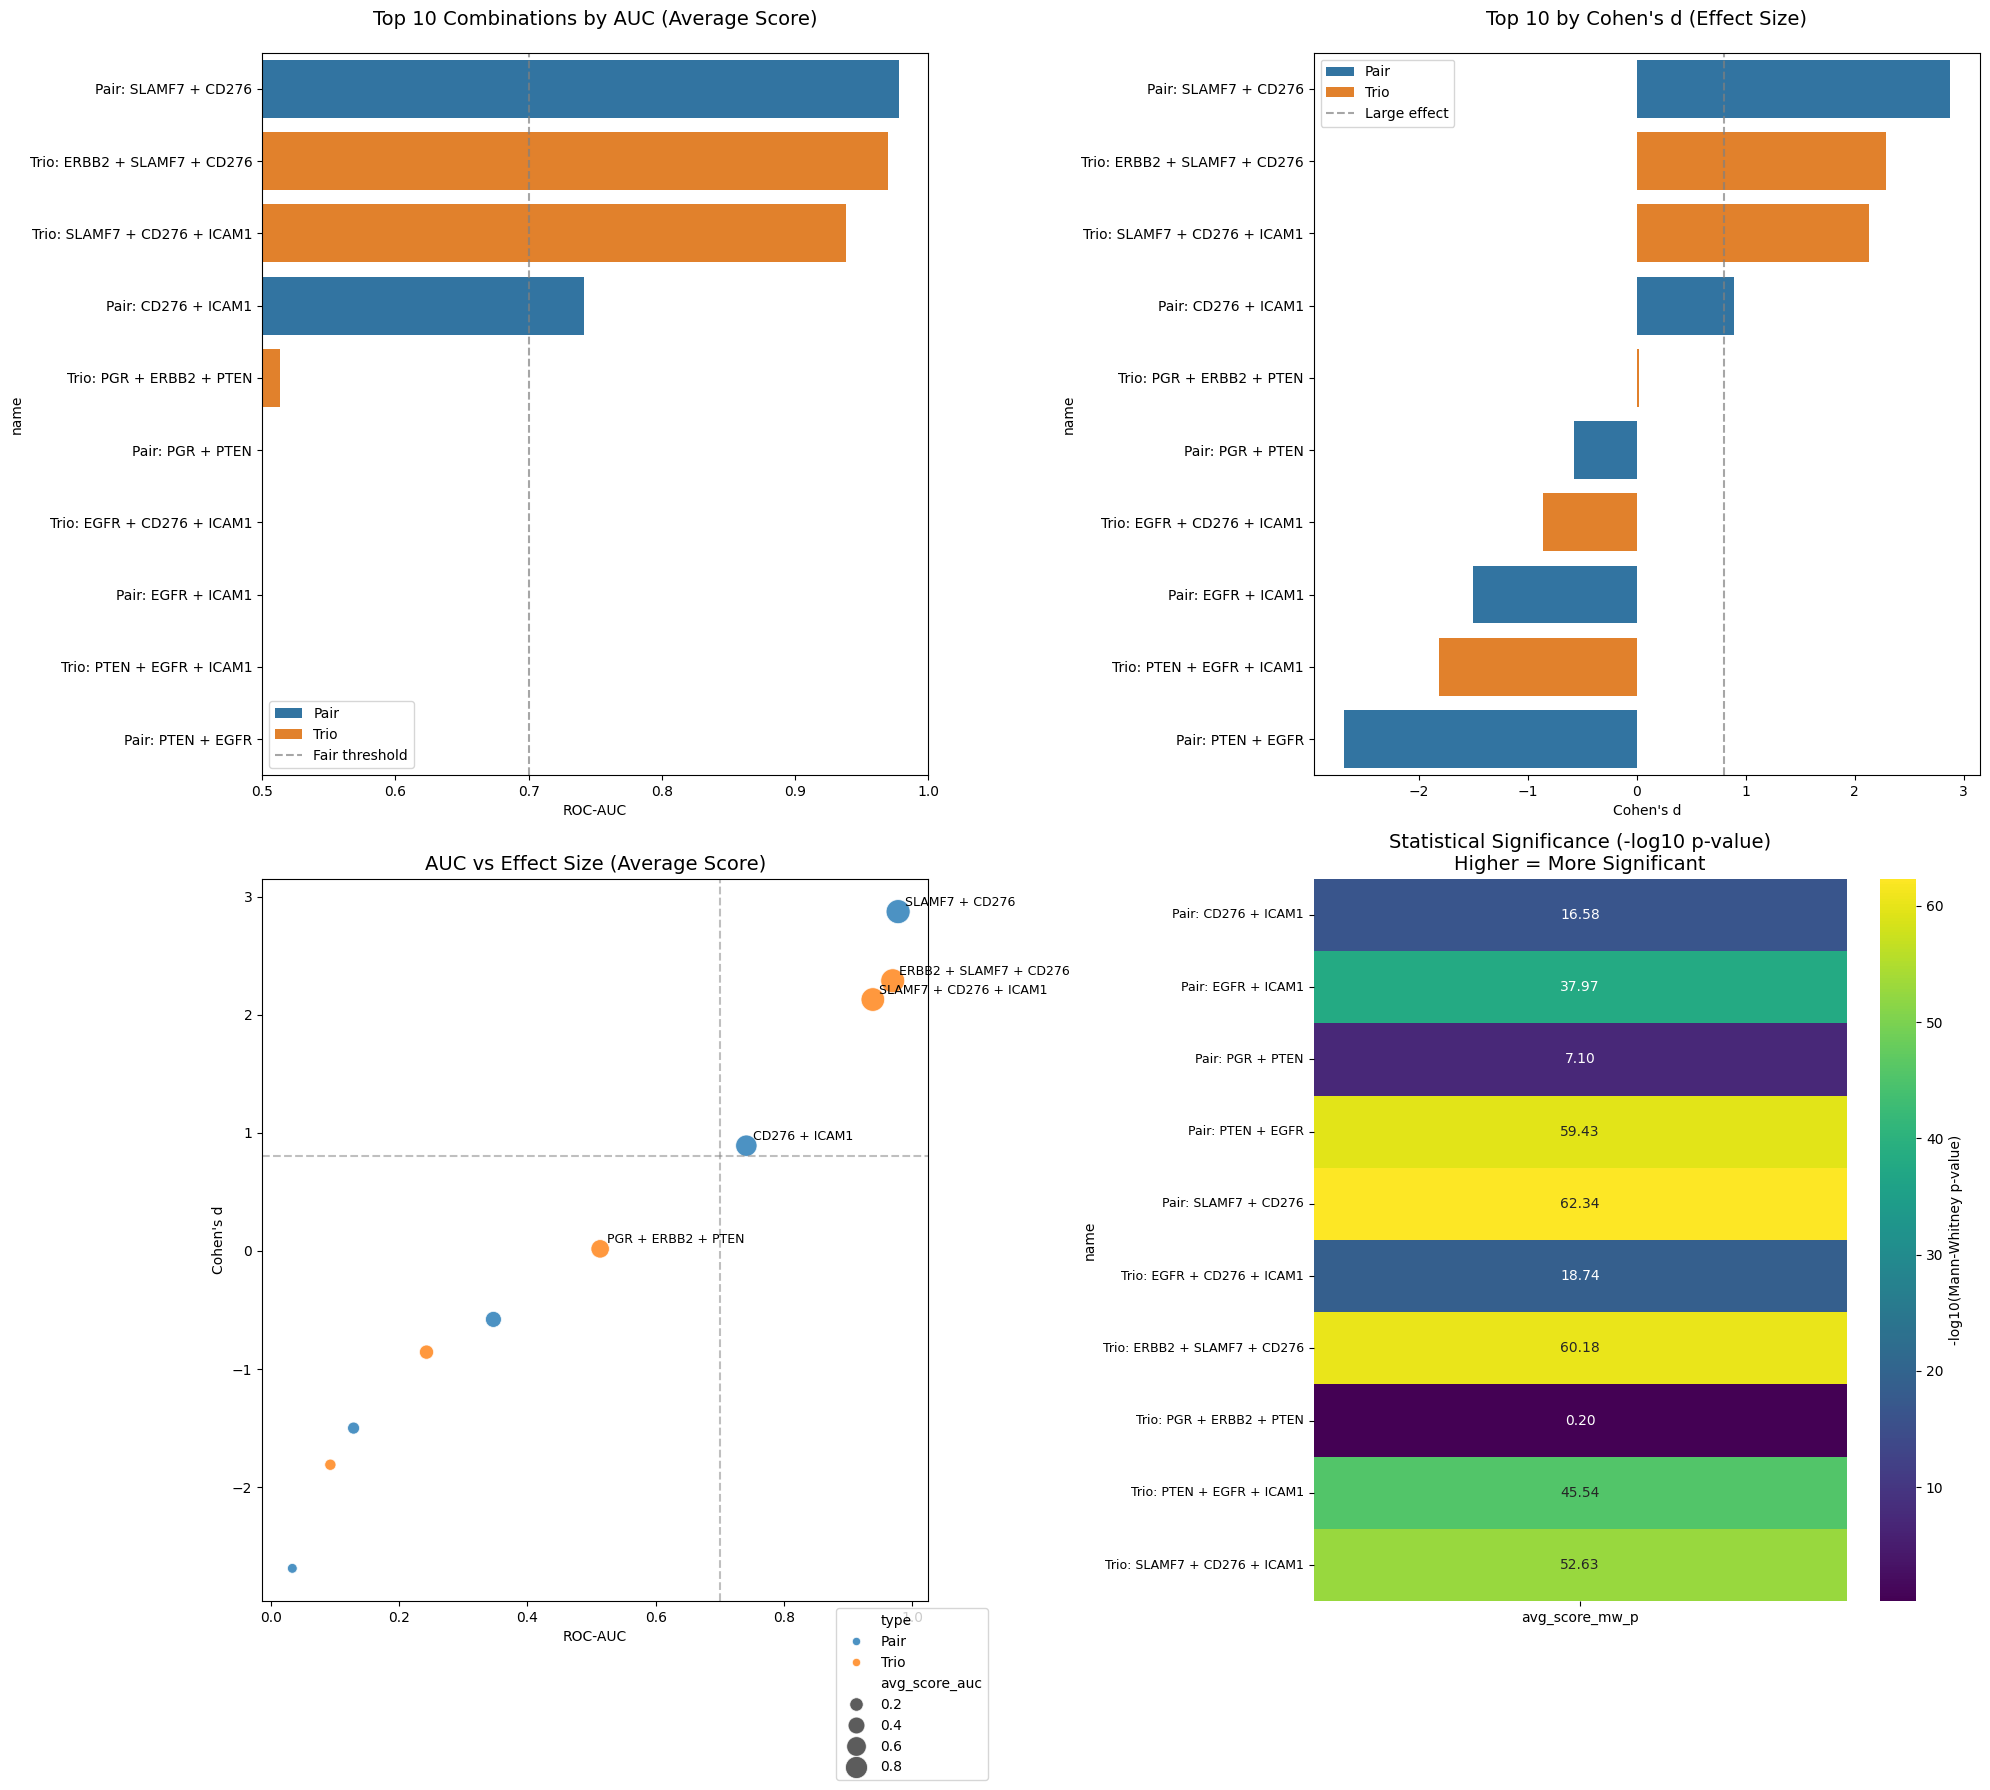

In [16]:
# converting all_results to dataframe
results_df = pd.DataFrame(all_results1)

# Extract pair/trio type for coloring
results_df['type'] = results_df['name'].apply(lambda x: 'Pair' if 'Pair' in x else 'Trio')

# reshape data to make plotting easier
melted = results_df.melt(
    id_vars=['name', 'type', 'genes'],
    value_vars=['avg_score_auc', 'pca_score_auc', 'geo_mean_auc'],
    var_name='composite_method',
    value_name='AUC'
)

#removing '_auc' string from melted['composite_method']
melted['composite_method'] = melted['composite_method'].str.replace('_auc', '')

#Defining main visualizations
#adding titles, axis labels and other visulization aids
#setting figure size
plt.figure(figsize=(20, 18))

# AUC Bar Plot, Average Score
plt.subplot(2, 2, 1)
top_auc = results_df.nlargest(10, 'avg_score_auc')
sns.barplot(
    data=top_auc,
    x='avg_score_auc',
    y='name',
    hue='type',
    palette={'Pair': '#1f77b4', 'Trio': '#ff7f0e'}
)
plt.title('Top 10 Combinations by AUC (Average Score)', fontsize=14, pad=20)
plt.xlabel('ROC-AUC')
plt.xlim(0.5, 1.0)
plt.axvline(0.7, color='gray', linestyle='--', alpha=0.7, label='Fair threshold')
plt.legend()

# Bar Plot of Cohen's d score
plt.subplot(2, 2, 2)
top_d = results_df.nlargest(10, 'avg_score_cohen_d')
sns.barplot(
    data=top_d,
    x='avg_score_cohen_d',
    y='name',
    hue='type',
    palette={'Pair': '#1f77b4', 'Trio': '#ff7f0e'}
)
plt.title("Top 10 by Cohen's d (Effect Size)", fontsize=14, pad=20)
plt.xlabel("Cohen's d")
plt.axvline(0.8, color='gray', linestyle='--', alpha=0.7, label='Large effect')
plt.legend()

# AUC vs Cohen's d Scatter Plot
plt.subplot(2, 2, 3)
sns.scatterplot(
    data=results_df,
    x='avg_score_auc',
    y='avg_score_cohen_d',
    hue='type',
    size='avg_score_auc',
    sizes=(50, 300),
    alpha=0.8,
    palette={'Pair': '#1f77b4', 'Trio': '#ff7f0e'}
)
plt.title('AUC vs Effect Size (Average Score)', fontsize=14)
plt.xlabel('ROC-AUC')
plt.ylabel("Cohen's d")
plt.axvline(0.7, color='gray', linestyle='--', alpha=0.5)
plt.axhline(0.8, color='gray', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.1, 0), loc='upper right')

# Add labels for top points
for i, row in results_df.nlargest(5, 'avg_score_auc').iterrows():
    plt.text(row['avg_score_auc'] + 0.01, row['avg_score_cohen_d'] + 0.05,
             row['name'].split(': ')[-1], fontsize=9)

# P-value Heatmap (significance)
plt.subplot(2, 2, 4)
piv = results_df.pivot_table(
    values='avg_score_mw_p',
    index='name',
    aggfunc='first'
).astype(float)

# Convert to -log10(p) for better visualization
piv_log = -np.log10(piv)
sns.heatmap(piv_log, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': '-log10(Mann-Whitney p-value)'})
plt.title('Statistical Significance (-log10 p-value)\nHigher = More Significant', fontsize=14)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

### Autoencoder gene groups

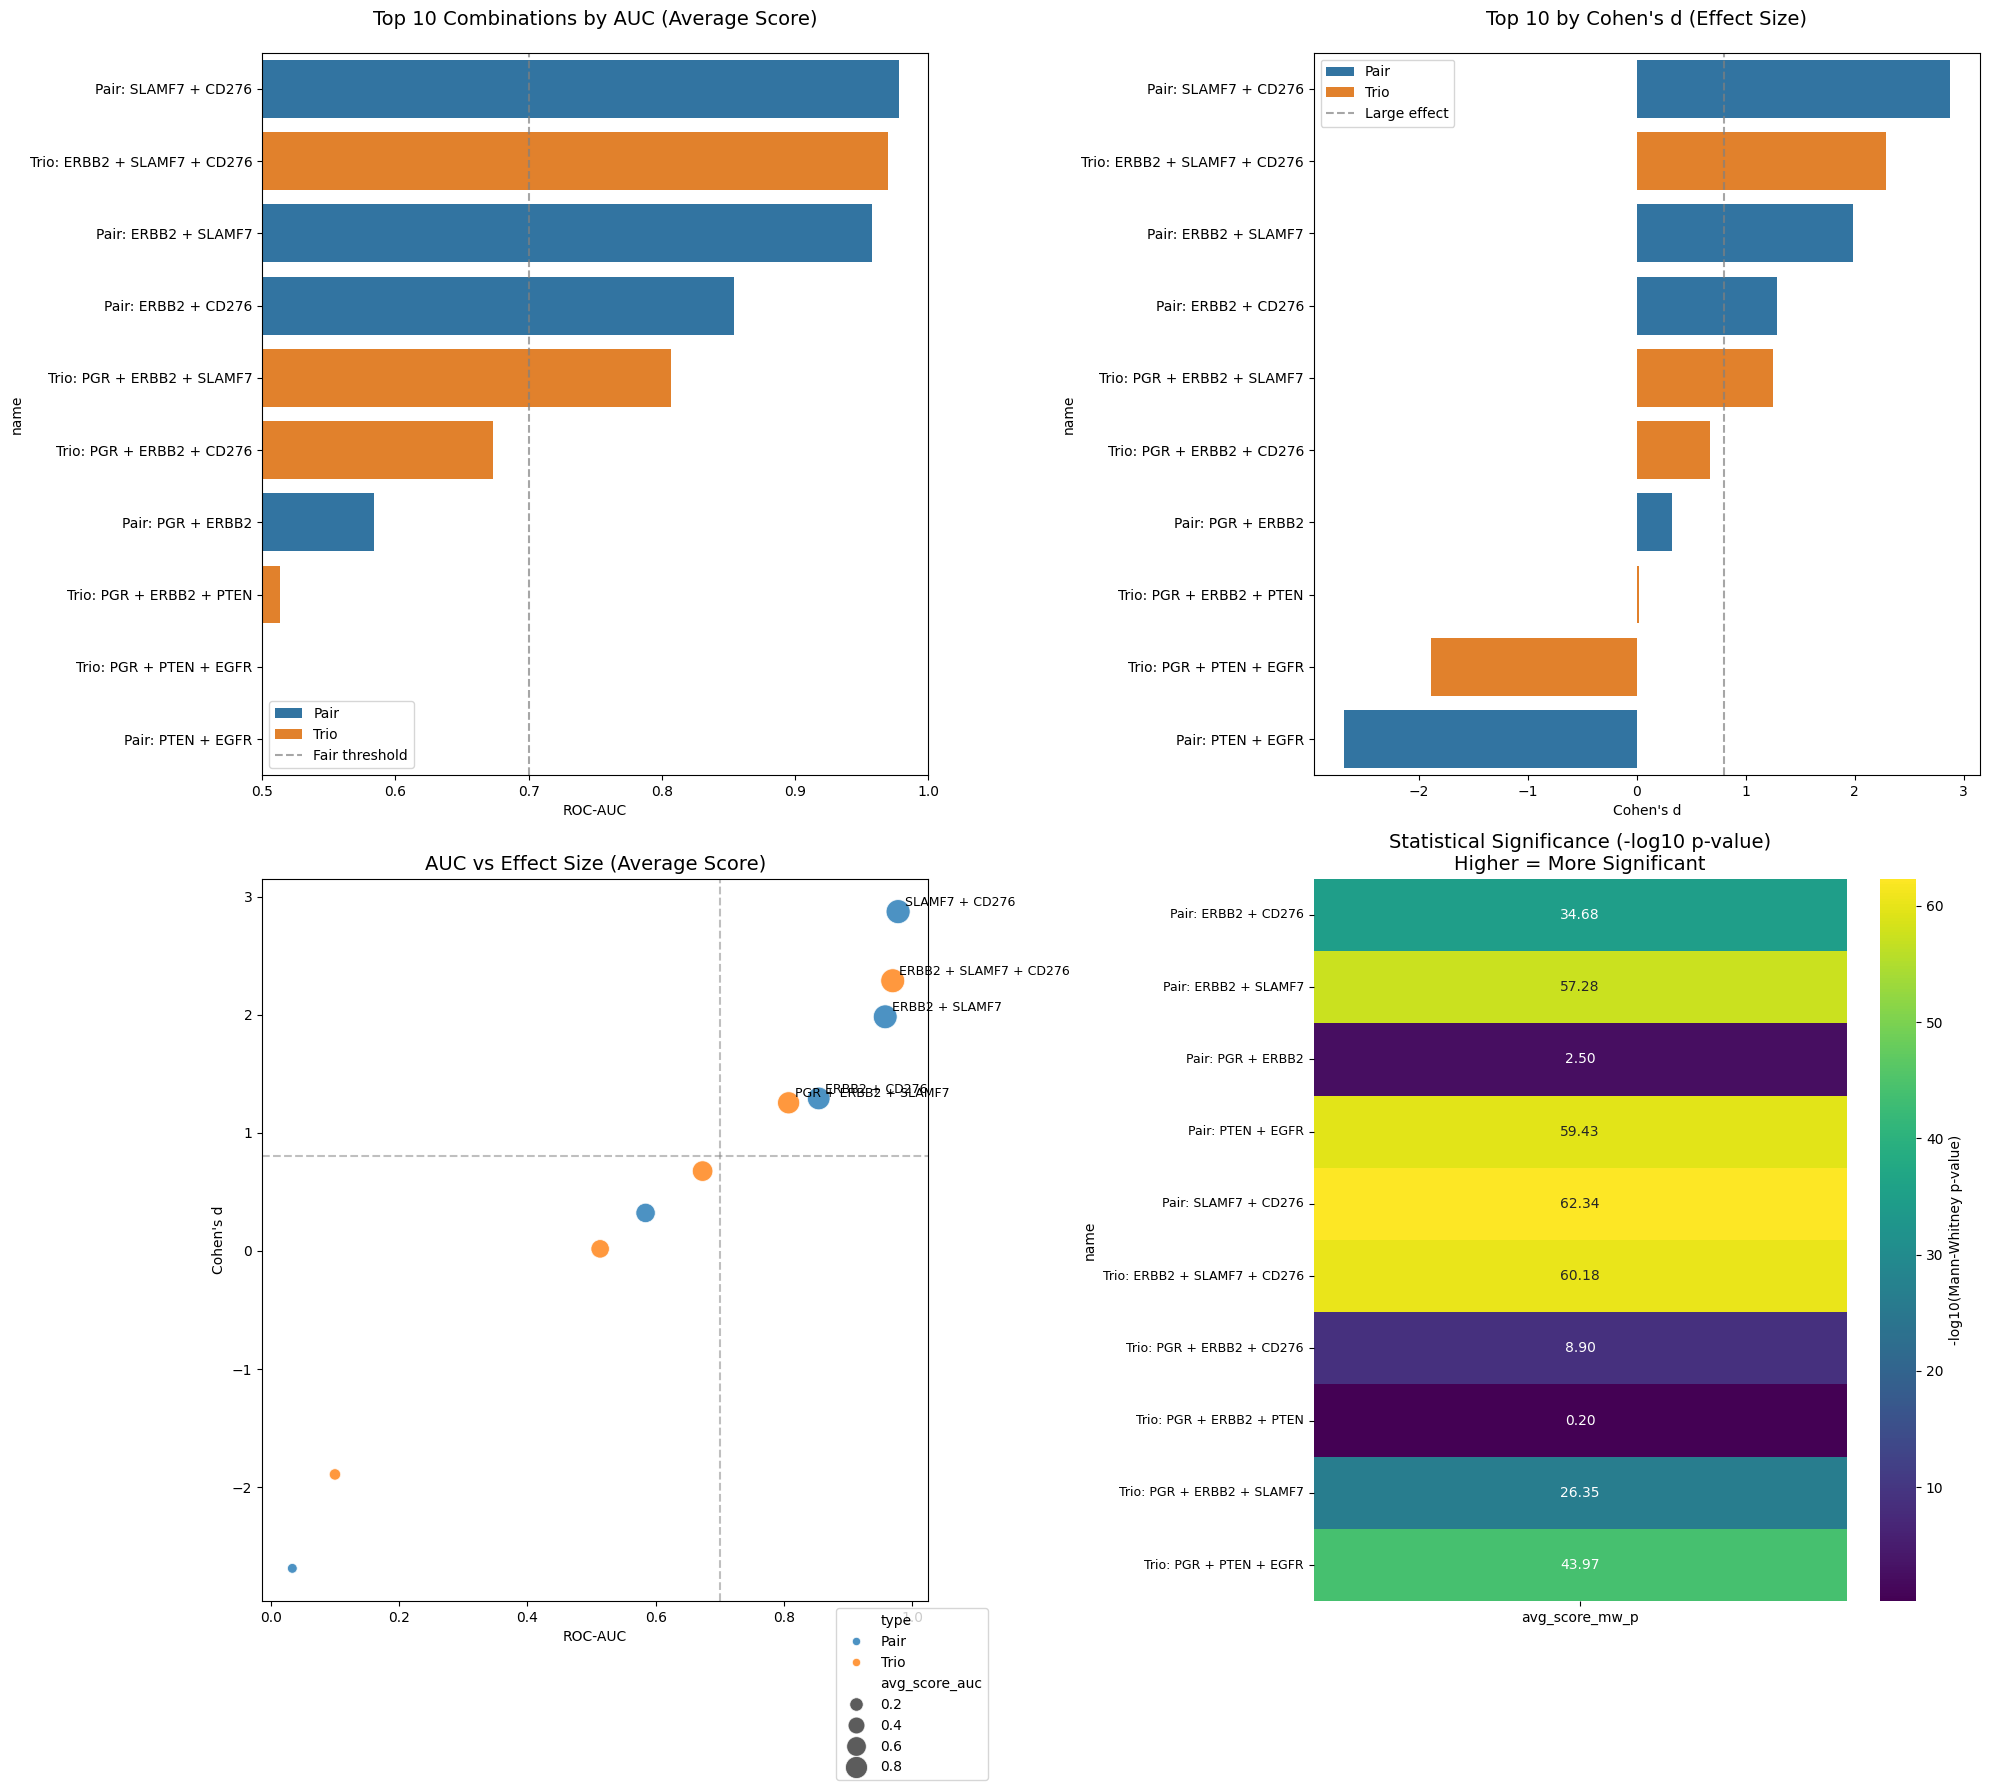

In [17]:
# converting all_results to dataframe
results_df = pd.DataFrame(all_results2)

# Extract pair/trio type for coloring
results_df['type'] = results_df['name'].apply(lambda x: 'Pair' if 'Pair' in x else 'Trio')

# reshape data to make plotting easier
melted = results_df.melt(
    id_vars=['name', 'type', 'genes'],
    value_vars=['avg_score_auc', 'pca_score_auc', 'geo_mean_auc'],
    var_name='composite_method',
    value_name='AUC'
)

#removing '_auc' string from melted['composite_method']
melted['composite_method'] = melted['composite_method'].str.replace('_auc', '')

#Defining main visualizations
#adding titles, axis labels and other visulization aids
#setting figure size
plt.figure(figsize=(20, 18))

# AUC Bar Plot, Average Score
plt.subplot(2, 2, 1)
top_auc = results_df.nlargest(10, 'avg_score_auc')
sns.barplot(
    data=top_auc,
    x='avg_score_auc',
    y='name',
    hue='type',
    palette={'Pair': '#1f77b4', 'Trio': '#ff7f0e'}
)
plt.title('Top 10 Combinations by AUC (Average Score)', fontsize=14, pad=20)
plt.xlabel('ROC-AUC')
plt.xlim(0.5, 1.0)
plt.axvline(0.7, color='gray', linestyle='--', alpha=0.7, label='Fair threshold')
plt.legend()

# Bar Plot of Cohen's d score
plt.subplot(2, 2, 2)
top_d = results_df.nlargest(10, 'avg_score_cohen_d')
sns.barplot(
    data=top_d,
    x='avg_score_cohen_d',
    y='name',
    hue='type',
    palette={'Pair': '#1f77b4', 'Trio': '#ff7f0e'}
)
plt.title("Top 10 by Cohen's d (Effect Size)", fontsize=14, pad=20)
plt.xlabel("Cohen's d")
plt.axvline(0.8, color='gray', linestyle='--', alpha=0.7, label='Large effect')
plt.legend()

# AUC vs Cohen's d Scatter Plot
plt.subplot(2, 2, 3)
sns.scatterplot(
    data=results_df,
    x='avg_score_auc',
    y='avg_score_cohen_d',
    hue='type',
    size='avg_score_auc',
    sizes=(50, 300),
    alpha=0.8,
    palette={'Pair': '#1f77b4', 'Trio': '#ff7f0e'}
)
plt.title('AUC vs Effect Size (Average Score)', fontsize=14)
plt.xlabel('ROC-AUC')
plt.ylabel("Cohen's d")
plt.axvline(0.7, color='gray', linestyle='--', alpha=0.5)
plt.axhline(0.8, color='gray', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.1, 0), loc='upper right')

# Add labels for top points
for i, row in results_df.nlargest(5, 'avg_score_auc').iterrows():
    plt.text(row['avg_score_auc'] + 0.01, row['avg_score_cohen_d'] + 0.05,
             row['name'].split(': ')[-1], fontsize=9)

# P-value Heatmap (significance)
plt.subplot(2, 2, 4)
piv = results_df.pivot_table(
    values='avg_score_mw_p',
    index='name',
    aggfunc='first'
).astype(float)

# Convert to -log10(p) for better visualization
piv_log = -np.log10(piv)
sns.heatmap(piv_log, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': '-log10(Mann-Whitney p-value)'})
plt.title('Statistical Significance (-log10 p-value)\nHigher = More Significant', fontsize=14)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

Epoch 1/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8617 - loss: 0.4808 - val_accuracy: 0.8776 - val_loss: 0.3496
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9116 - loss: 0.2337 - val_accuracy: 0.8776 - val_loss: 0.2192
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9116 - loss: 0.1473 - val_accuracy: 0.8776 - val_loss: 0.1699
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9116 - loss: 0.1153 - val_accuracy: 0.8776 - val_loss: 0.1477
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9116 - loss: 0.1014 - val_accuracy: 0.8776 - val_loss: 0.1359
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9116 - loss: 0.0940 - val_accuracy: 0.8776 - val_loss: 0.1291
Epoch 7/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9116 - loss: 0.0891 - val_accuracy: 0.8776 - val_loss: 0.1260
Epoch 8/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9116 - loss: 0.0856 - val_accuracy: 0.8776 - val_loss:

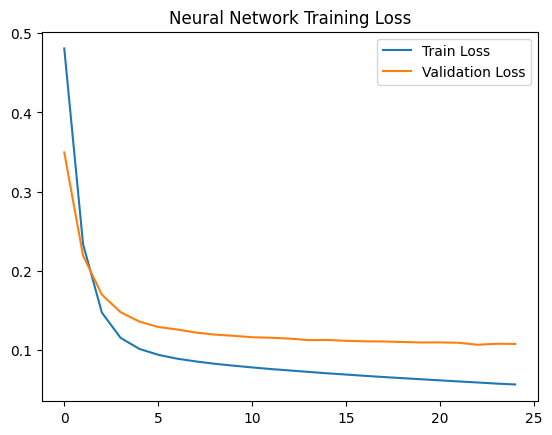

In [19]:
# Deep Learning Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# 1. Features and Labels

GENES = ['PGR', 'ERBB2', 'EGFR', 'PTEN', 'SLAMF7', 'CD276', 'ICAM1']

X = combined[GENES]
y = combined['label']

# 2. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale Data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Build Neural Network

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Train Model

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=25,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

# 6. Evaluate Model

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

# 7. Plot Training

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Neural Network Training Loss")
plt.show()